# COLM Norm Reasoning Traces — Exploratory Analysis

Explores the reasoning output from the Qwen2.5-72B-AWQ extraction of Raz norms
from 10 fiction novels. Each row is one identified norm (exploded from chunk-level output).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))

REASONING_PATH = os.environ.get('REASONING_PATH',
    '/share/pierson/matt/UAIR/outputs/2026-03-20_historical_norms/23-12-53/COLM_norms_fiction/outputs/reasoning/reasoning.parquet')

df = pd.read_parquet(REASONING_PATH)
print(f'Loaded {len(df):,} rows from {REASONING_PATH}')
print(f'Columns: {list(df.columns)}')
df.head(2)

Loaded 11,289 rows from /share/pierson/matt/UAIR/outputs/2026-03-20_historical_norms/23-12-53/COLM_norms_fiction/outputs/reasoning/reasoning.parquet
Columns: ['gutenberg_id', 'chunk_id', 'article_text', 'chunk_size', 'book_title', 'book_author', 'book_summary', 'generated_text', 'has_prescriptive_content', 'has_norms', 'norm_count', 'reasoning_trace', 'norm_snippet', 'preliminary_normative_force', 'governs_information_flow', 'reasoning_error', 'norm_index']


,gutenberg_id,chunk_id,article_text,chunk_size,book_title,book_author,book_summary,generated_text,has_prescriptive_content,has_norms,norm_count,reasoning_trace,norm_snippet,preliminary_normative_force,governs_information_flow,reasoning_error,norm_index
0,1342,0,PRIDE.\n and\...,5632,Pride and Prejudice,Jane Austen,"In the early 19th century, during the Napoleon...","{\n ""norms"": [],\n ""has_prescriptive_content...",False,False,0,None,None,None,None,None,NaN
1,1342,1,rable book. Although Miss Austen\nalways liked...,5461,Pride and Prejudice,Jane Austen,"In the early 19th century, during the Napoleon...","{\n ""norms"": [],\n ""has_prescriptive_content...",False,False,0,None,None,None,None,None,NaN


## 1. Corpus overview

In [2]:
n_chunks = df[['gutenberg_id', 'chunk_id']].drop_duplicates().shape[0]
n_norms = df['has_norms'].sum()
n_empty = (~df['has_norms']).sum()
n_errors = df['reasoning_error'].notna().sum()

print(f'Total rows (one per norm):  {len(df):,}')
print(f'Unique chunks processed:    {n_chunks:,}')
print(f'Rows with norms:            {n_norms:,} ({n_norms/len(df)*100:.1f}%)')
print(f'Rows without norms:         {n_empty:,} ({n_empty/len(df)*100:.1f}%)')
print(f'Parse errors:               {n_errors:,}')
print(f'Avg norms per chunk:        {n_norms / n_chunks:.1f}')

Total rows (one per norm):  11,289
Unique chunks processed:    2,993
Rows with norms:            10,500 (93.0%)
Rows without norms:         789 (7.0%)
Parse errors:               2
Avg norms per chunk:        3.5


## 2. Norms per novel

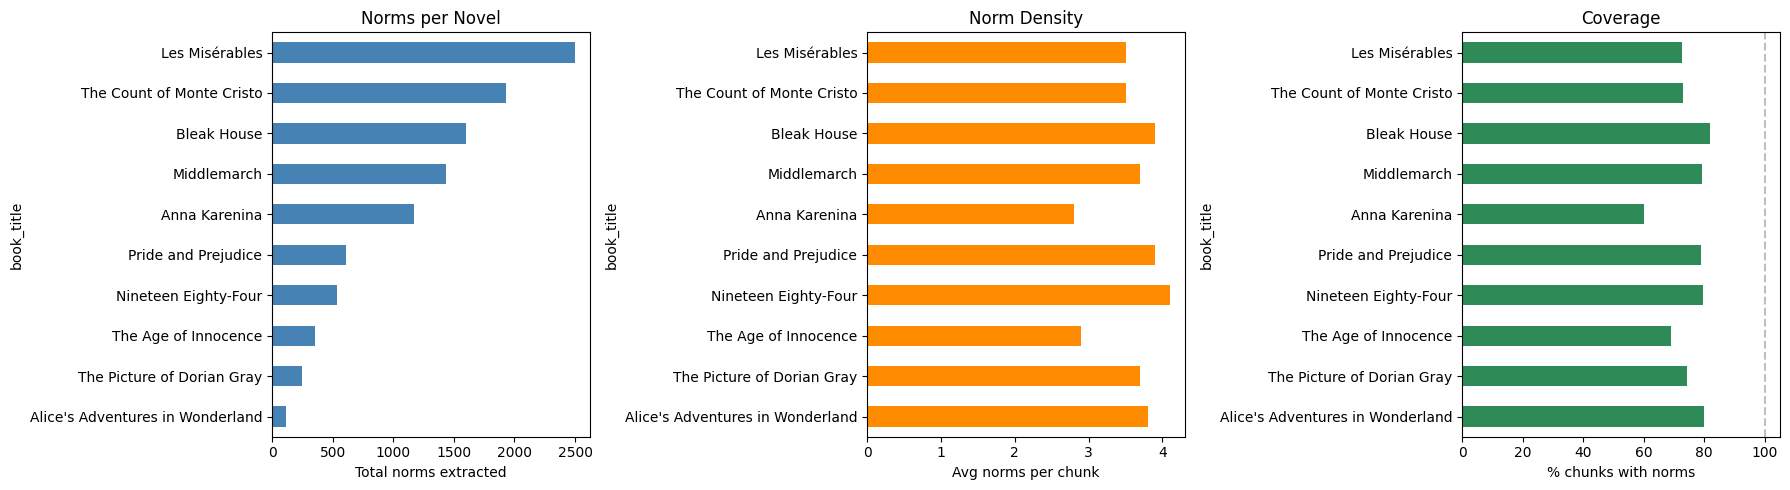

,total_norms,chunks_with_norms,info_flow_norms,total_chunks,norms_per_chunk,pct_chunks_with_norms
book_title,,,,,,
Les Misérables,2498,512,131,706,3.5,72.5
The Count of Monte Cristo,1929,402,219,550,3.5,73.1
Bleak House,1597,337,221,412,3.9,81.8
Middlemarch,1436,311,141,393,3.7,79.1
Anna Karenina,1175,255,85,424,2.8,60.1
Pride and Prejudice,611,123,78,156,3.9,78.8
Nineteen Eighty-Four,539,106,98,133,4.1,79.7
The Age of Innocence,358,85,33,123,2.9,69.1
The Picture of Dorian Gray,244,49,14,66,3.7,74.2


In [3]:
norms_by_book = df[df['has_norms']].groupby('book_title').agg(
    total_norms=('norm_index', 'count'),
    chunks_with_norms=('chunk_id', 'nunique'),
    info_flow_norms=('governs_information_flow', lambda x: (x == True).sum() + (x == 'True').sum()),
).sort_values('total_norms', ascending=True)

# Total chunks per book (deduplicate before grouping)
total_chunks = df[['book_title', 'gutenberg_id', 'chunk_id']].drop_duplicates().groupby('book_title').size()
norms_by_book['total_chunks'] = total_chunks
norms_by_book['norms_per_chunk'] = (norms_by_book['total_norms'] / norms_by_book['total_chunks']).round(1)
norms_by_book['pct_chunks_with_norms'] = (norms_by_book['chunks_with_norms'] / norms_by_book['total_chunks'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

norms_by_book['total_norms'].plot.barh(ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total norms extracted')
axes[0].set_title('Norms per Novel')

norms_by_book['norms_per_chunk'].plot.barh(ax=axes[1], color='darkorange')
axes[1].set_xlabel('Avg norms per chunk')
axes[1].set_title('Norm Density')

norms_by_book['pct_chunks_with_norms'].plot.barh(ax=axes[2], color='seagreen')
axes[2].set_xlabel('% chunks with norms')
axes[2].set_title('Coverage')
axes[2].axvline(100, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

norms_by_book.sort_values('total_norms', ascending=False)

## 3. Normative force distribution

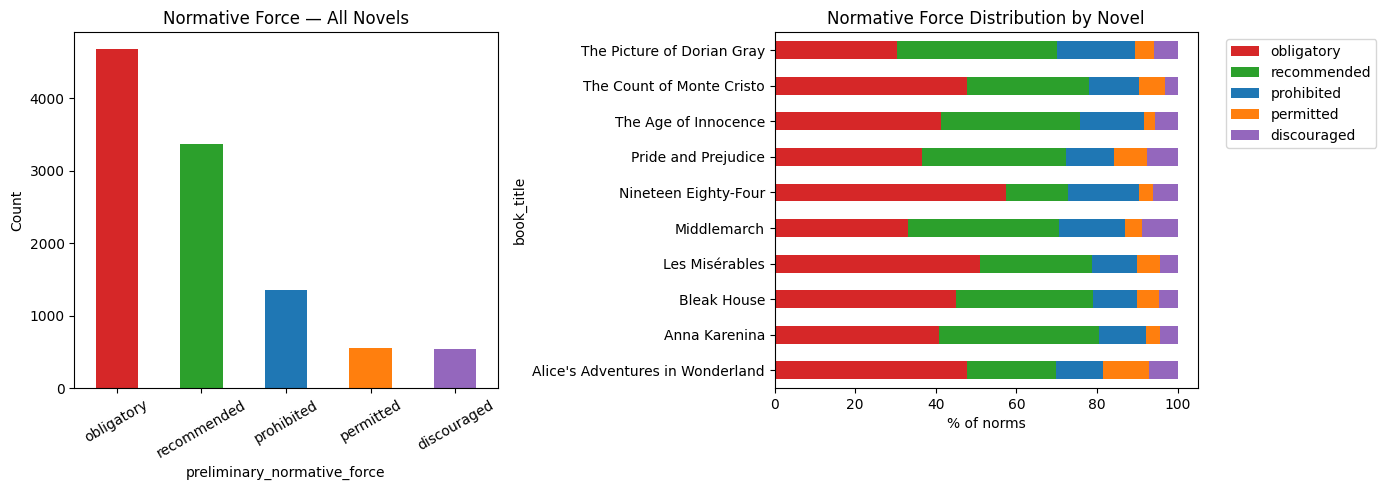

In [4]:
force_order = ['obligatory', 'recommended', 'prohibited', 'permitted', 'discouraged']
force_colors = {'obligatory': '#d62728', 'recommended': '#2ca02c', 'prohibited': '#1f77b4',
                'permitted': '#ff7f0e', 'discouraged': '#9467bd'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
force_counts = df['preliminary_normative_force'].value_counts().reindex(force_order)
force_counts.plot.bar(ax=axes[0], color=[force_colors.get(f, 'gray') for f in force_order])
axes[0].set_title('Normative Force — All Novels')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Per novel (stacked)
force_by_book = pd.crosstab(df['book_title'], df['preliminary_normative_force'])
force_by_book = force_by_book.reindex(columns=force_order, fill_value=0)
force_by_book_pct = force_by_book.div(force_by_book.sum(axis=1), axis=0) * 100
force_by_book_pct.sort_index().plot.barh(
    stacked=True, ax=axes[1],
    color=[force_colors.get(f, 'gray') for f in force_order]
)
axes[1].set_xlabel('% of norms')
axes[1].set_title('Normative Force Distribution by Novel')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Information flow norms vs. non-informational norms

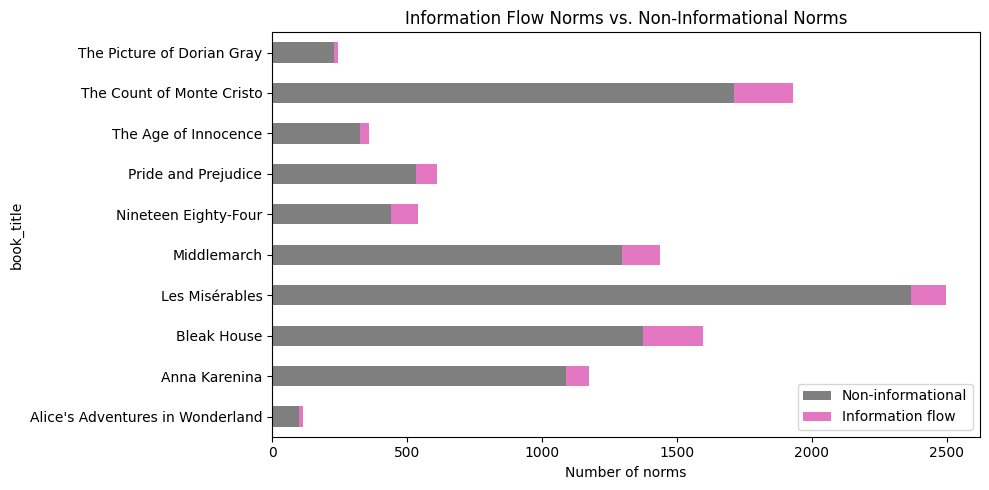

Information flow norms: 1,033 / 10,500 (9.8%)



,info_flow_count,total,non_info_count,info_flow_pct
book_title,,,,
Nineteen Eighty-Four,98,539,441,18.2
Bleak House,221,1597,1376,13.8
Pride and Prejudice,78,611,533,12.8
Alice's Adventures in Wonderland,13,113,100,11.5
The Count of Monte Cristo,219,1929,1710,11.4
Middlemarch,141,1436,1295,9.8
The Age of Innocence,33,358,325,9.2
Anna Karenina,85,1175,1090,7.2
The Picture of Dorian Gray,14,244,230,5.7


In [5]:
# Normalize the governs_information_flow column
df['info_flow'] = df['governs_information_flow'].apply(
    lambda x: True if x is True or x == 'True' or x == 'true' else False
)

flow_by_book = df[df['has_norms']].groupby('book_title')['info_flow'].agg(
    info_flow_count='sum',
    total='count'
)
flow_by_book['non_info_count'] = flow_by_book['total'] - flow_by_book['info_flow_count']
flow_by_book['info_flow_pct'] = (flow_by_book['info_flow_count'] / flow_by_book['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
flow_by_book[['non_info_count', 'info_flow_count']].sort_index().plot.barh(
    stacked=True, ax=ax, color=['#7f7f7f', '#e377c2']
)
ax.set_xlabel('Number of norms')
ax.set_title('Information Flow Norms vs. Non-Informational Norms')
ax.legend(['Non-informational', 'Information flow'], loc='lower right')
plt.tight_layout()
plt.show()

total_info = df['info_flow'].sum()
print(f'Information flow norms: {total_info:,} / {n_norms:,} ({total_info/n_norms*100:.1f}%)')
print()
flow_by_book.sort_values('info_flow_pct', ascending=False)

## 5. Norm count distribution per chunk

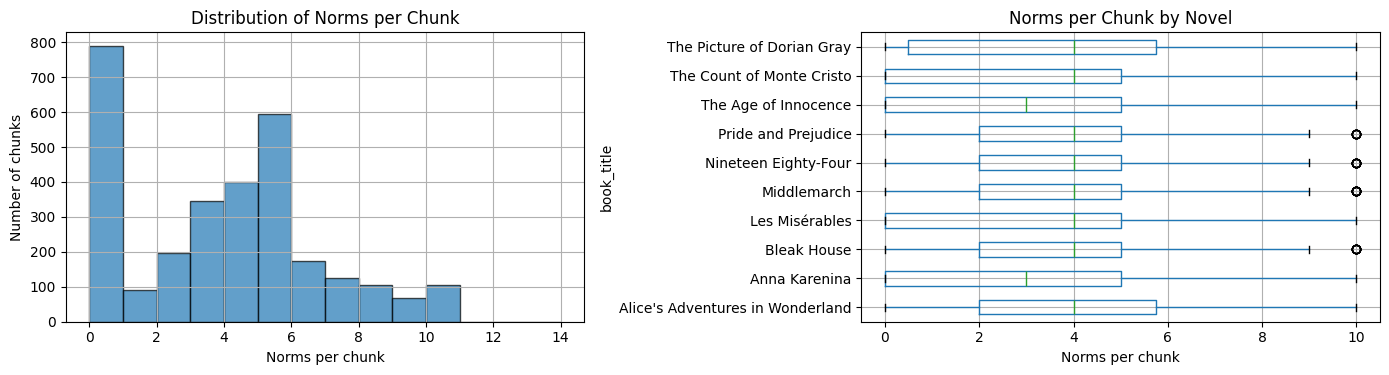

Chunks with 0 norms: 789 / 2993
Max norms in a single chunk: 10


In [6]:
norms_per_chunk = df.groupby(['gutenberg_id', 'chunk_id']).agg(
    n_norms=('has_norms', 'sum'),
    book_title=('book_title', 'first')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

norms_per_chunk['n_norms'].hist(bins=range(0, 15), ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Norms per chunk')
axes[0].set_ylabel('Number of chunks')
axes[0].set_title('Distribution of Norms per Chunk')

norms_per_chunk.boxplot(column='n_norms', by='book_title', ax=axes[1], vert=False)
axes[1].set_xlabel('Norms per chunk')
axes[1].set_title('Norms per Chunk by Novel')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'Chunks with 0 norms: {(norms_per_chunk["n_norms"] == 0).sum()} / {len(norms_per_chunk)}')
print(f'Max norms in a single chunk: {norms_per_chunk["n_norms"].max()}')

## 6. Sample reasoning traces

Qualitative inspection of a few high-quality reasoning traces.

In [7]:
# Pick one norm from each of 5 diverse novels
sample_books = ['Pride and Prejudice', 'Nineteen Eighty-Four', 'Les Misérables',
                'Anna Karenina', 'Alice\'s Adventures in Wonderland']

for book in sample_books:
    subset = df[(df['book_title'] == book) & (df['has_norms'])]
    if subset.empty:
        continue
    row = subset.sample(1, random_state=42).iloc[0]
    print(f'{"═" * 70}')
    print(f'{book} — chunk {row["chunk_id"]}, norm {int(row.get("norm_index", 0))}')
    print(f'Force: {row["preliminary_normative_force"]} | Info flow: {row["governs_information_flow"]}')
    print(f'{"─" * 70}')
    print(f'Snippet: {str(row.get("norm_snippet", ""))[:300]}')
    print(f'{"─" * 70}')
    trace = str(row.get('reasoning_trace', ''))
    print(f'Reasoning ({len(trace)} chars):')
    print(trace[:500])
    if len(trace) > 500:
        print('...')
    print()

══════════════════════════════════════════════════════════════════════
Pride and Prejudice — chunk 25, norm 1
Force: recommended | Info flow: False
──────────────────────────────────────────────────────────────────────
Snippet: Do let the portraits of your uncle and aunt Philips be placed in the gallery at Pemberley. Put them next to your great-uncle the judge.
──────────────────────────────────────────────────────────────────────
Reasoning (477 chars):
The norm subject is the person being addressed (likely Mr. Darcy). The prescriptive element is 'do let,' which implies a recommendation. The norm act is to place the portraits of the uncle and aunt Philips in the gallery at Pemberley and to put them next to the great-uncle the judge. The condition of application is when the gallery at Pemberley is being arranged. This norm is recommended because it is a suggestion to honor family members, but it is not strictly obligatory.

═══════════════════════════════════════════════════════════════

## 7. Empty chunks — what text has no norms?

In [8]:
empty_chunks = df[~df['has_norms']][['book_title', 'chunk_id', 'article_text']].drop_duplicates()

print(f'Chunks with no norms: {len(empty_chunks)}')
print()
print('Distribution by book:')
print(empty_chunks['book_title'].value_counts().to_string())
print()
print('Sample empty chunks (first 200 chars):')
for _, row in empty_chunks.sample(min(5, len(empty_chunks)), random_state=42).iterrows():
    print(f'  [{row["book_title"]}, chunk {row["chunk_id"]}]: {row["article_text"][:200]}...')
    print()

Chunks with no norms: 789

Distribution by book:
book_title
Les Misérables                      194
Anna Karenina                       169
The Count of Monte Cristo           148
Middlemarch                          82
Bleak House                          75
The Age of Innocence                 38
Pride and Prejudice                  33
Nineteen Eighty-Four                 27
The Picture of Dorian Gray           17
Alice's Adventures in Wonderland      6

Sample empty chunks (first 200 chars):
  [Anna Karenina, chunk 197]: bisova, a pretty
dancing-girl whom he had just taken under his protection, the coral
necklace he had promised her the evening before, and behind the scenes
in the dim daylight of the theater, managed ...

  [Middlemarch, chunk 10]: he felt the
disadvantage of loneliness, the need of that cheerful companionship
with which the presence of youth can lighten or vary the serious toils
of maturity. And he delivered this statement with...

  [Bleak House, chunk 216]: to
be

## 8. Parse errors

In [9]:
errors = df[df['reasoning_error'].notna()]
print(f'Parse errors: {len(errors)}')
if len(errors) > 0:
    for _, row in errors.iterrows():
        print(f'  [{row["book_title"]}, chunk {row["chunk_id"]}]: {row["reasoning_error"]}')
        print(f'  Raw output (first 300 chars): {str(row["generated_text"])[:300]}')
        print()

Parse errors: 2
  [The Age of Innocence, chunk 8]: Expecting ',' delimiter: line 3510 column 6 (char 24075)
  Raw output (first 300 chars): {
  "norms": [
    {
      "original_text_snippet": "Nothing about his betrothed pleased him more than her resolute determination to carry to its utmost limit that ritual of ignoring the 'unpleasant' in which they had both been brought up.",
      "reasoning": "The norm subject is 'the betrothed' (M

  [The Age of Innocence, chunk 109]: Expecting ',' delimiter: line 2052 column 6 (char 22518)
  Raw output (first 300 chars): {
  "norms": [
    {
      "original_text_snippet": "May--"  
				
      
				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
      				
 



## 9. Reasoning trace length distribution

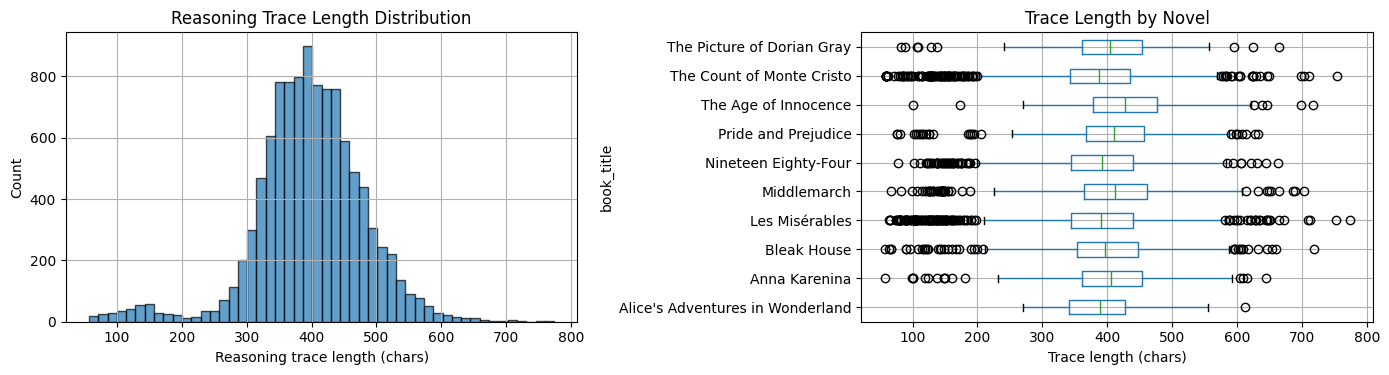

Trace length stats: mean=369, median=391, max=774


In [10]:
df['trace_len'] = df['reasoning_trace'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['has_norms']]['trace_len'].hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Reasoning trace length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Reasoning Trace Length Distribution')

df[df['has_norms']].boxplot(column='trace_len', by='book_title', ax=axes[1], vert=False)
axes[1].set_xlabel('Trace length (chars)')
axes[1].set_title('Trace Length by Novel')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'Trace length stats: mean={df["trace_len"].mean():.0f}, '
      f'median={df["trace_len"].median():.0f}, '
      f'max={df["trace_len"].max()}')